In [1]:
import pandas as pd

df= pd.read_csv("SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
# 1. Which products generate the most revenue?

In [2]:
#To understand the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [4]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [5]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [6]:
# fix the date column

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

In [ ]:
#remove hidden spaces

In [12]:
df.columns = df.columns.str.strip()

In [ ]:
#converted date fields into datetime format to support accurate time - series analsyis and aggregation

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [14]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [15]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

product_name
Newell 334                                                                               9999991191699
Dana Swing-Arm Lamps                                                                       99932171717
Tenex Door Stop, Black                                             99881761231325317644192307881818160
Hon Training Table, with Bottom Storage                                                          99867
Boston School Pro Electric Pencil Sharpener, 1670                                    99741981869312499
Hamilton Beach Refrigerator, White                              9971,3457976641,9936641,3458974,136747
Eaton Memo Slips, Recycled                                               99643337273627414114382311464
Tenex Box, Blue                                      9959132233171493317991310417173317333322134513...
OIC Clamps, Metal                                                         9954402036801666804080405420
Advantus Stacking Tray, Durable                             

In [ ]:
I checked the data type to confirm whether the column was numeric before performing calculations

In [18]:
df["sales"].dtype

dtype('O')

In [ ]:
#Converted the sales column from string to numeric format, handling invalid values to ensure accurate aggregation and visualization

In [19]:
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

In [20]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64


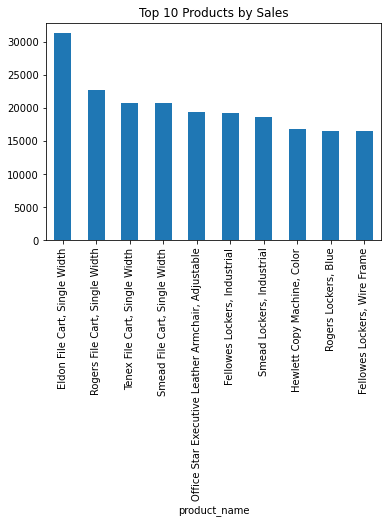

In [21]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.show()

In [ ]:
# The Eldon File Cart - Single Width is the top-performing product by total sales, indicating a strong demand and a significant contribution to overall revenue.

In [22]:
top_products.head(1)

product_name
Eldon File Cart, Single Width    31319.0
Name: sales, dtype: float64

In [ ]:
# insight
- The Eldon File Cart- Single Width generated the highest revenue (~$31k), making it the top-performing product and a key driver of overall sales.

In [ ]:
#2. Which regions perform best?

In [23]:
region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)
print(region_sales)

region
Central           1806638.0
South             1031101.0
North              790546.0
Oceania            625382.0
EMEA               575562.0
Africa             538115.0
Southeast Asia     532172.0
North Asia         453686.0
West               424173.0
Central Asia       389506.0
East               366492.0
Caribbean          251441.0
Canada              50314.0
Name: sales, dtype: float64


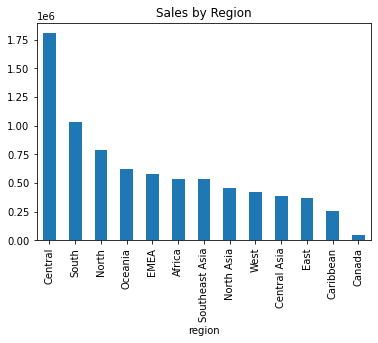

In [24]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

In [ ]:
#The Central region generated the highest total sales, indicating it is the strongest performing market and a key contributor to overall revenue.

In [25]:
region_sales.head(1)

region
Central    1806638.0
Name: sales, dtype: float64

In [ ]:
#Insight
- The Central regon generated the highest total sales, suggesting strong market performance and highlighting it as a key revenue-driving region

In [ ]:
# 3. How do sales change over time?

In [26]:
monthly_sales = df.resample("M", on="order_date")["sales"].sum()
print(monthly_sales)

order_date
2011-01-31     89456.0
2011-02-28     88803.0
2011-03-31     94863.0
2011-04-30     89444.0
2011-05-31     93225.0
2011-06-30    124757.0
2011-07-31    101817.0
2011-08-31    125298.0
2011-09-30    143024.0
2011-10-31    122003.0
2011-11-30    135181.0
2011-12-31    170280.0
2012-01-31    100122.0
2012-02-29     95932.0
2012-03-31    122610.0
2012-04-30    107711.0
2012-05-31    148012.0
2012-06-30    158094.0
2012-07-31    121529.0
2012-08-31    155344.0
2012-09-30    158281.0
2012-10-31    144711.0
2012-11-30    193655.0
2012-12-31    175498.0
2013-01-31    122101.0
2013-02-28    108367.0
2013-03-31    136972.0
2013-04-30    140307.0
2013-05-31    166502.0
2013-06-30    222300.0
2013-07-31    156047.0
2013-08-31    202666.0
2013-09-30    230476.0
2013-10-31    173704.0
2013-11-30    228932.0
2013-12-31    218647.0
2014-01-31    164016.0
2014-02-28    162694.0
2014-03-31    203234.0
2014-04-30    194260.0
2014-05-31    184875.0
2014-06-30    239912.0
2014-07-31    174718.0


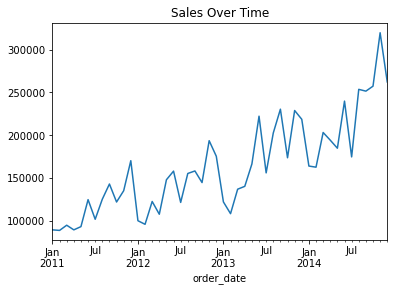

In [27]:
monthly_sales.plot()
plt.title("Sales Over Time")
plt.show()

In [ ]:
#insight 
- Sales demonstrate a steady upward trend over time, indicating consistent growth and increasaing demand.

In [ ]:
## 📈 Key Insights

- The Eldon File Cart – Single Width is the top-performing product, contributing the highest revenue.
- The Central region generated the most sales, indicating it is the strongest performing market.
- Sales show a steady upward trend over time, suggesting consistent business growth and increasing demand.